# Dataset Review — mỗi dataset một section (Smart Parking thesis, UIT)

Notebook tái lập: **tải on-the-fly** (Kaggle / Roboflow / Google Drive) + **overview** từng bộ (đếm ảnh, format nhãn, tên lớp, độ *gần* chủ thể, 10 ảnh mẫu vẽ nhãn).
Mỗi dataset = **một section độc lập** — chạy riêng section bạn cần.

Nguyên tắc: **không đoán** — số liệu đọc từ file thật. Liên quan: `research/2026-07-28-dataset-inventory-verified.md`, `research/2026-07-30-vehicle-framing-report.md`.

> ⚠️ **Run-All** chỉ tải các bộ nhỏ. Bộ nặng (>100 MB: tanhphp, duydieu, lmphmthanh) bị **gate** bởi `DOWNLOAD_LARGE` — đặt `True` ở Setup rồi chạy section đó.

## 0. Setup — deps, credentials, thư mục, cờ

In [1]:
import importlib, subprocess, sys
def _ensure(pkgs):
    for imp, pip in pkgs:
        try: importlib.import_module(imp)
        except ImportError:
            subprocess.run([sys.executable,"-m","pip","install","-q",pip], check=False)
_ensure([("cv2","opencv-python-headless"),("PIL","pillow"),("numpy","numpy"),
         ("matplotlib","matplotlib"),("yaml","pyyaml"),("kaggle","kaggle"),
         ("roboflow","roboflow"),("gdown","gdown")])
print("deps ok")

deps ok


In [2]:
import os, collections, subprocess, shutil
from pathlib import Path
import numpy as np, cv2
import matplotlib.pyplot as plt

# CLI (kaggle/gdown ở ~/.local/bin) vào PATH của kernel
for _p in (Path.home()/".local/bin","/usr/local/bin","/opt/homebrew/bin"):
    if str(_p) not in os.environ.get("PATH","").split(os.pathsep):
        os.environ["PATH"]=str(_p)+os.pathsep+os.environ.get("PATH","")

def load_env(dotenv):
    p=Path(dotenv)
    if p.exists():
        for line in p.read_text().splitlines():
            line=line.strip()
            if line and not line.startswith("#") and "=" in line:
                k,v=line.split("=",1); os.environ.setdefault(k.strip(),v.strip())
REPO=Path.cwd()
while REPO!=REPO.parent and not (REPO/".git").exists(): REPO=REPO.parent
load_env(REPO/".env")
ROBOFLOW_KEY=os.environ.get("ROBOFLOW_API_KEY")
DATA_DIR=Path(os.environ.get("DATASET_DIR", Path.home()/".cache"/"uit-thesis-datasets"))
DATA_DIR.mkdir(parents=True, exist_ok=True)

# CỜ: tải bộ nặng (>100MB) hay không. Đổi True để chạy tanhphp/duydieu/lmphmthanh.
DOWNLOAD_LARGE = False

print("repo:",REPO)
print("roboflow key:", "SET" if ROBOFLOW_KEY else "MISSING (.env)")
print("kaggle creds:", "OK" if (Path.home()/".kaggle/kaggle.json").exists() else "MISSING")
print("DATA_DIR:",DATA_DIR," | DOWNLOAD_LARGE:",DOWNLOAD_LARGE)

repo: /Users/ducqhle/Documents/workspace/UIT2026-DoAnCuoiKi
roboflow key: SET
kaggle creds: OK
DATA_DIR: /Users/ducqhle/.cache/uit-thesis-datasets  | DOWNLOAD_LARGE: False


## 1. Helper dùng chung — `download()` + `overview()`

In [3]:
def _unzip_all(dest: Path):
    for z in dest.rglob("*.zip"):
        try: shutil.unpack_archive(str(z),str(z.parent)); z.unlink()
        except Exception as e: print("unzip skip",z.name,e)

def download(entry) -> Path:
    key,src,ref=entry["key"],entry["source"],entry["ref"]
    dest=DATA_DIR/key
    if dest.exists() and any(dest.rglob("*")):
        print(f"[{key}] đã có → bỏ qua tải"); return dest
    dest.mkdir(parents=True, exist_ok=True)
    print(f"[{key}] tải {src}: {ref}")
    if src=="kaggle":
        subprocess.run(["kaggle","datasets","download","-d",ref,"-p",str(dest),"--unzip"],check=False); _unzip_all(dest)
    elif src=="roboflow":
        if not ROBOFLOW_KEY: print("  ✗ thiếu ROBOFLOW_API_KEY"); return dest
        from roboflow import Roboflow
        rf=Roboflow(api_key=ROBOFLOW_KEY)
        (rf.workspace(ref["workspace"]).project(ref["project"])
           .version(ref["version"]).download(ref.get("fmt","yolov8"),location=str(dest)))
    elif src=="gdrive":
        import gdown
        try: gdown.download_folder(id=ref,output=str(dest),quiet=True)
        except Exception: gdown.download(id=ref,output=str(dest/'file'),quiet=True)
        _unzip_all(dest)
    elif src=="local":
        return Path(ref)
    return dest

# ---- overview ----
IMG_EXT={'.jpg','.jpeg','.png','.bmp','.webp'}
def read_yaml_classes(root: Path):
    import yaml
    for y in list(root.rglob("*.yaml"))+list(root.rglob("*.yml")):
        try:
            d=yaml.safe_load(y.read_text())
            if isinstance(d,dict) and "names" in d: return d.get("nc"),d.get("names"),y.name
        except Exception: pass
    return None,None,None

def parse_label(p: Path):
    # -> list dict(cls, area, aspect, kind, coords)
    out=[]
    try:
        for l in p.read_text().splitlines():
            t=l.split()
            if not t or not t[0].lstrip('-').isdigit(): continue
            c=int(t[0]); v=[float(x) for x in t[1:]]
            if len(v)==4: cx,cy,w,h=v; kind="bbox"; coords=(cx,cy,w,h)
            elif len(v)==7: cx,cy,w,h=v[:4]; kind="pose"; coords=(cx,cy,w,h)
            elif len(v)>=6 and len(v)%2==0:
                xs=v[0::2]; ys=v[1::2]; w=max(xs)-min(xs); h=max(ys)-min(ys)
                kind="poly"; coords=list(zip(xs,ys))
            else: continue
            if 0<w<=1.01 and 0<h<=1.01:
                out.append(dict(cls=c,area=w*h,aspect=(w/h if h else 0),kind=kind,coords=coords))
    except Exception: pass
    return out

def _labels_for(img: Path):
    for c in (img.with_suffix('.txt'),
              Path(str(img).replace('/images/','/labels/')).with_suffix('.txt'),
              img.parent.parent/'labels'/(img.stem+'.txt')):
        if c.exists(): return c
    return None

def overview(root: Path, key="", n_show=10):
    root=Path(root)
    imgs=[p for p in root.rglob('*') if p.suffix.lower() in IMG_EXT]
    txts=[p for p in root.rglob('*.txt') if p.name.lower() not in ('classes.txt','readme.txt')]
    ext=collections.Counter(p.suffix.lower() for p in root.rglob('*') if p.is_file())
    print("="*72); print(f"DATASET: {key or root.name}  @ {root}"); print("="*72)
    print(f"images={len(imgs)}  label_txt={len(txts)}  ext={dict(ext.most_common(8))}")
    nc,names,yname=read_yaml_classes(root)
    if names is not None: print(f"classes (yaml {yname}): nc={nc} names={names}")
    dom=[]; kinds=collections.Counter(); per_cls=collections.defaultdict(list); labeled=[]
    for im in imgs:
        lp=_labels_for(im)
        if not lp: continue
        bs=parse_label(lp)
        if not bs: continue
        labeled.append((im,lp,bs))
        for b in bs: kinds[b["kind"]]+=1; per_cls[b["cls"]].append(b["area"])
        dom.append(max(b["area"] for b in bs))
    if dom:
        dm=np.array(dom); band=lambda lo,hi:((dm>=lo)&(dm<hi)).mean()*100
        print(f"format: {dict(kinds)}")
        print(f"dominant-area: tiny<2%={band(0,.02):.0f}% 2-8%={band(.02,.08):.0f}% "
              f"8-25%={band(.08,.25):.0f}% >=25%={(dm>=.25).mean()*100:.0f}%  => close(>=8%)={(dm>=.08).mean()*100:.0f}%")
        print("per-class median area:", {c:round(float(np.median(v)),3) for c,v in sorted(per_cls.items())})
    elif not txts and imgs:
        cc=collections.Counter(p.parent.name for p in imgs)
        print("format: folder=class. class counts:", dict(cc.most_common(12)))
    elif txts and not dom:
        print("format: txt không phải YOLO (vd chuỗi OCR) → xem ảnh mẫu")
    _montage(imgs, labeled, n_show, key)

def _montage(imgs, labeled, n_show, key):
    import random; random.seed(1)
    picks = random.sample(labeled,min(n_show,len(labeled))) if labeled else \
            [(p,None,None) for p in random.sample(imgs,min(n_show,len(imgs)))] if imgs else []
    if not picks: print("(no images)"); return
    cols=5; rows=(len(picks)+cols-1)//cols
    fig,axs=plt.subplots(rows,cols,figsize=(cols*2.6,rows*2.0)); axs=np.array(axs).reshape(-1)
    for ax in axs: ax.axis('off')
    for i,(im,lp,bs) in enumerate(picks):
        img=cv2.imread(str(im))
        if img is None: continue
        h,w=img.shape[:2]
        for b in (bs or []):
            if b["kind"] in ("bbox","pose"):
                cx,cy,bw,bh=b["coords"]
                cv2.rectangle(img,(int((cx-bw/2)*w),int((cy-bh/2)*h)),(int((cx+bw/2)*w),int((cy+bh/2)*h)),(0,255,0),2)
            else:
                cv2.polylines(img,[np.array([[int(x*w),int(y*h)] for x,y in b["coords"]],np.int32)],True,(0,165,255),2)
        axs[i].imshow(cv2.cvtColor(img,cv2.COLOR_BGR2RGB))
        dm=max((b["area"] for b in bs),default=0) if bs else 0
        axs[i].set_title(f"{im.name[:18]}\n{('dom='+format(dm*100,'.1f')+'%') if bs else ''}",fontsize=7)
    fig.suptitle(f"{key} — {len(picks)} mẫu",fontsize=10); plt.tight_layout(); plt.show()

def run_section(entry, heavy=False):
    if heavy and not DOWNLOAD_LARGE:
        print(f"[{entry['key']}] NẶNG (>100MB) — đặt DOWNLOAD_LARGE=True ở Setup rồi chạy lại section này."); return
    if entry["source"]=="roboflow" and not ROBOFLOW_KEY:
        print(f"[{entry['key']}] cần ROBOFLOW_API_KEY trong .env."); return
    p=download(entry); overview(p, key=entry["key"], n_show=10)

---
# PHẦN A — Biển số (detect + OCR + ký tự)

## A1. plate_tanhphp — detect biển ⭐ (~1 GB, nặng)

**Kaggle** `tanhphp/vietnamese-license-plates` · 2.255 ảnh · YOLO bbox nc=1 · dùng **detect biển chính**. Box=biển nên diện tích nhỏ là bình thường.

In [4]:
entry = dict(key="plate_tanhphp", source="kaggle", ref="tanhphp/vietnamese-license-plates", module="detect biển")
run_section(entry, heavy=True)

[plate_tanhphp] NẶNG (>100MB) — đặt DOWNLOAD_LARGE=True ở Setup rồi chạy lại section này.


## A2. plate_duydieu — detect + layout BSD/BSV ⭐ (~1 GB, nặng)

**Kaggle** `duydieunguyen/licenseplates` · 4.578 ảnh · **YOLO-SEG polygon** nc=2 `['BSD','BSV']` (biển dài/vuông, verify aspect 2.53/0.90). **Ảnh cận 1 xe** → proxy loại xe ô tô/xe máy. Biển nhỏ nhưng xe gần → xem ảnh.

In [5]:
entry = dict(key="plate_duydieu", source="kaggle", ref="duydieunguyen/licenseplates", module="detect+layout BSD/BSV")
run_section(entry, heavy=True)

[plate_duydieu] NẶNG (>100MB) — đặt DOWNLOAD_LARGE=True ở Setup rồi chạy lại section này.


## A3. plate_bomaich — detect biển ✅ (237 MB)

**Kaggle** `bomaich/vnlicenseplate` · 498 ảnh · YOLO bbox nc=1, split sẵn · ảnh cảnh đầy đủ · bổ sung detect. License: unknown.

[plate_bomaich] đã có → bỏ qua tải
DATASET: plate_bomaich  @ /Users/ducqhle/.cache/uit-thesis-datasets/plate_bomaich
images=498  label_txt=498  ext={'.txt': 498, '.jpg': 496, '.png': 2}
format: {'bbox': 780}
dominant-area: tiny<2%=6% 2-8%=78% 8-25%=15% >=25%=1%  => close(>=8%)=15%
per-class median area: {0: 0.042}


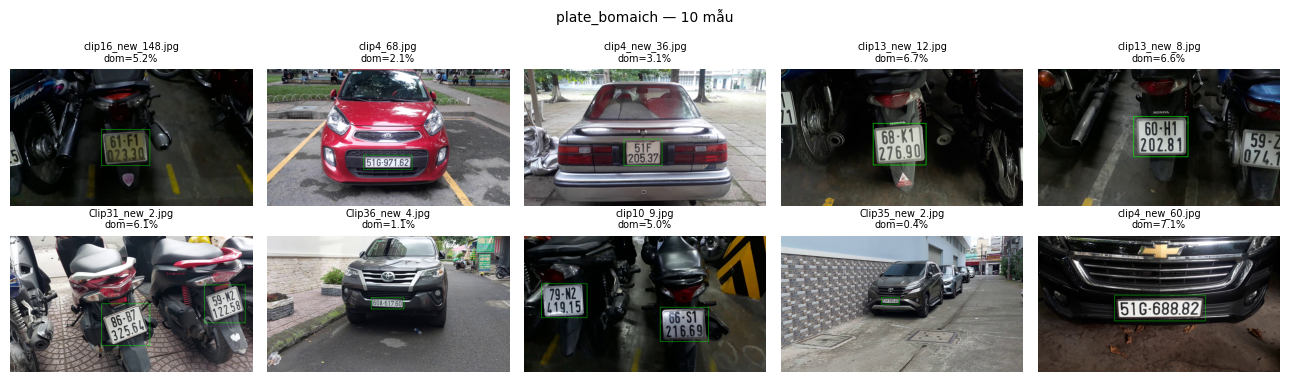

In [6]:
entry = dict(key="plate_bomaich", source="kaggle", ref="bomaich/vnlicenseplate", module="detect biển")
run_section(entry)

## A4. plate_ocr_topkek — OCR chuỗi ⭐ (63 MB)

**Kaggle** `topkek69/vietnamese-license-plate-ocr` · 12.190 (6.643 thật + 5.547 sinh) · crop + CSV chuỗi biển · **OCR chính**. Nhớ **tách generated/** khi đo.

[plate_ocr_topkek] đã có → bỏ qua tải
DATASET: plate_ocr_topkek  @ /Users/ducqhle/.cache/uit-thesis-datasets/plate_ocr_topkek
images=12190  label_txt=0  ext={'.jpg': 12190, '.csv': 2}
format: folder=class. class counts: {'cropped': 6643, 'generated': 5547}


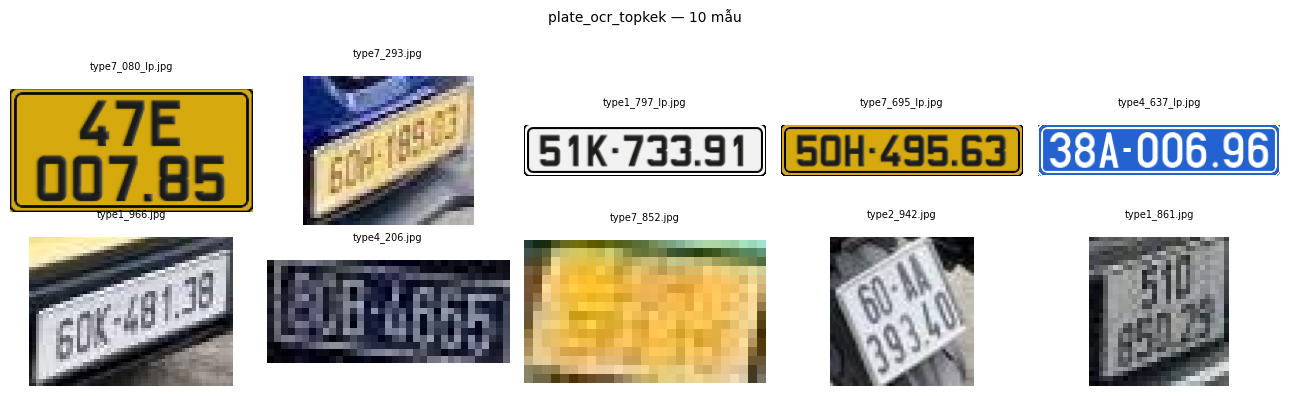

In [7]:
entry = dict(key="plate_ocr_topkek", source="kaggle", ref="topkek69/vietnamese-license-plate-ocr", module="OCR chuỗi")
run_section(entry)

## A5. motorbike_ocr_100 — OCR xe máy 2 hàng ✅ (2 MB)

**Kaggle** `dtkngan/100-bien-so-xe-may-ocr` · 116 ảnh · ảnh + txt chuỗi · **biển xe máy 2 hàng** → test set 2 hàng. License: apache-2.0.

[motorbike_ocr_100] đã có → bỏ qua tải
DATASET: motorbike_ocr_100  @ /Users/ducqhle/.cache/uit-thesis-datasets/motorbike_ocr_100
images=116  label_txt=116  ext={'.jpg': 116, '.txt': 116}
format: txt không phải YOLO (vd chuỗi OCR) → xem ảnh mẫu


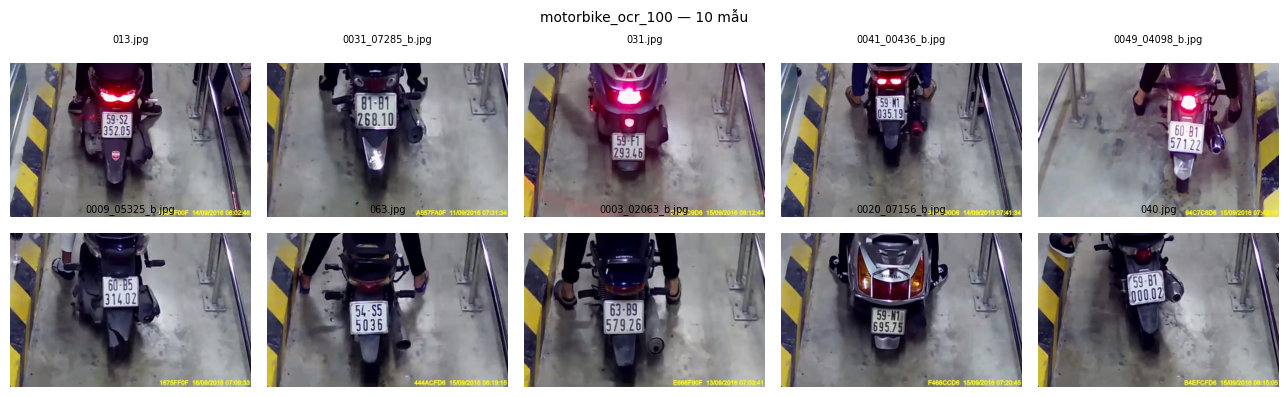

In [8]:
entry = dict(key="motorbike_ocr_100", source="kaggle", ref="dtkngan/100-bien-so-xe-may-ocr", module="OCR 2 hàng")
run_section(entry)

## A6. char_nql — ký tự ⚠️ (7 MB)

**Kaggle** `nguyenquanglinh0109/character-dataset-for-vietnam-license-plate` · 1.839 · **folder=class** 28×28 (0-9,A-Z + Noise) · **lệch class nặng** (M=4 vs F=148) → augment nếu dùng char-classifier.

[char_nql] đã có → bỏ qua tải
DATASET: char_nql  @ /Users/ducqhle/.cache/uit-thesis-datasets/char_nql
images=1839  label_txt=0  ext={'.png': 1839}
format: folder=class. class counts: {'F': 148, 'Noise': 124, 'G': 85, '0': 83, 'X': 78, '7': 73, '9': 71, '3': 71, 'P': 70, '2': 67, 'H': 65, '1': 62}


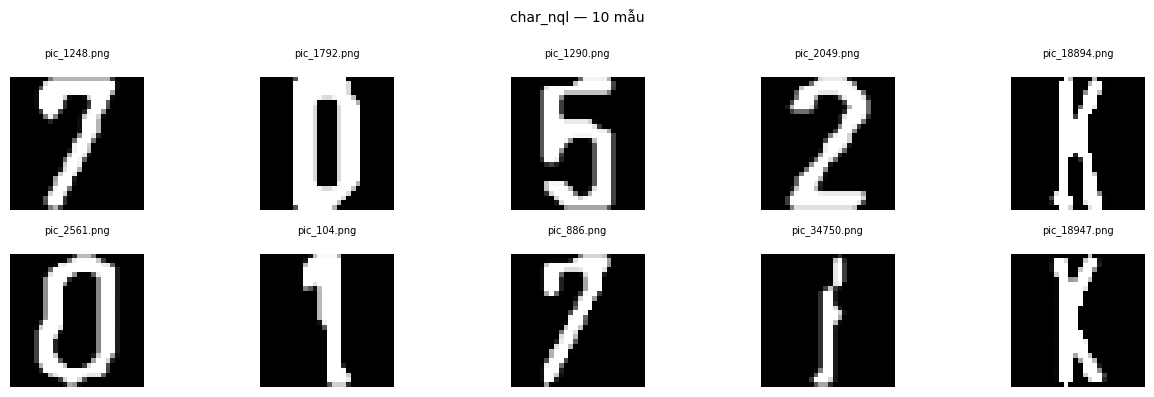

In [9]:
entry = dict(key="char_nql", source="kaggle", ref="nguyenquanglinh0109/character-dataset-for-vietnam-license-plate", module="ký tự")
run_section(entry)

---
# PHẦN B — Loại xe (framing filter: phải xe GẦN kiểu cam cổng)

## B1. vehicle_lmphmthanh — loại xe ❌ street-view (149 MB, nặng)

**Kaggle** `lmphmthanh/vietnam-vehicle-dataset` = mirror Roboflow `car-classification/vietnamese-vehicle v3` (CC BY 4.0). 2.361 ảnh YOLO. **Vấn đề:** nhãn `['0','1','2','3']` **không tên/nhập nhằng** (Roboflow trộn số+tên) + **cam đường trên cao** (street-view, không hợp cổng bãi). → chỉ **pretrain hình dạng**.

In [10]:
entry = dict(key="vehicle_lmphmthanh", source="kaggle", ref="lmphmthanh/vietnam-vehicle-dataset", module="loại xe")
run_section(entry, heavy=True)

[vehicle_lmphmthanh] NẶNG (>100MB) — đặt DOWNLOAD_LARGE=True ở Setup rồi chạy lại section này.


## B2. vehicle_cameraview — loại xe ❌ FAR (8 MB)

**Kaggle** `haihovan/vietnam-vehicles-camera-view` (CC BY 4.0) · 156 ảnh · YOLO **pose** nc=4 car/moto/truck/bus · **CCTV ngã tư xa, lệch class** (bus áp đảo, close≈10%). → loại khỏi loại-xe chính.

[vehicle_cameraview] đã có → bỏ qua tải
DATASET: vehicle_cameraview  @ /Users/ducqhle/.cache/uit-thesis-datasets/vehicle_cameraview
images=156  label_txt=156  ext={'.txt': 156, '.jpg': 156, '.yaml': 1}
classes (yaml data.yaml): nc=4 names={0: 'car', 3: 'bus', 2: 'truck', 1: 'motorcycle'}
format: {'pose': 3142}
dominant-area: tiny<2%=37% 2-8%=54% 8-25%=10% >=25%=0%  => close(>=8%)=10%
per-class median area: {0: 0.009, 1: 0.014, 2: 0.009, 3: 0.005}


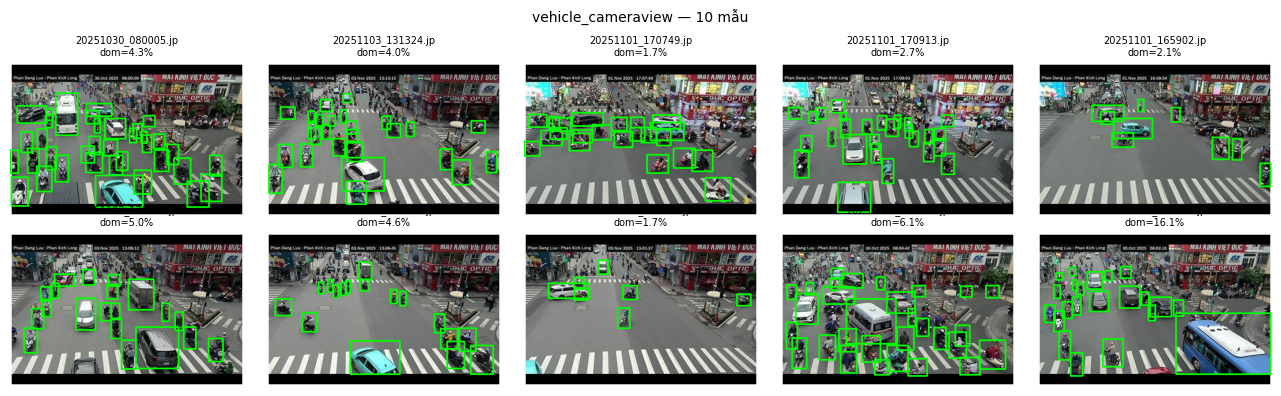

In [11]:
entry = dict(key="vehicle_cameraview", source="kaggle", ref="haihovan/vietnam-vehicles-camera-view", module="loại xe CCTV")
run_section(entry)

## B3. rf_vietnamese_vehicle — Roboflow gốc (cần API key)

**Roboflow** `car-classification/vietnamese-vehicle v3`. Truy vấn API cho thấy nhãn **trộn số + tên** (bẩn). Bản mirror = B1. Chạy nếu muốn tải gốc từ Roboflow (cần `ROBOFLOW_API_KEY`).

In [12]:
entry = dict(key="rf_vietnamese_vehicle", source="roboflow", ref=dict(workspace="car-classification", project="vietnamese-vehicle", version=3, fmt="yolov8"), module="loại xe gốc")
run_section(entry)

[rf_vietnamese_vehicle] tải roboflow: {'workspace': 'car-classification', 'project': 'vietnamese-vehicle', 'version': 3, 'fmt': 'yolov8'}
loading Roboflow workspace...
loading Roboflow project...
DATASET: rf_vietnamese_vehicle  @ /Users/ducqhle/.cache/uit-thesis-datasets/rf_vietnamese_vehicle
images=0  label_txt=0  ext={}
(no images)


---
## ➕ Thêm dataset MỚI để review

Điền `NEW` rồi chạy. `source` ∈ `kaggle|roboflow|gdrive|local`. Đặt `heavy=True` nếu >100 MB.

In [13]:
NEW = dict(
    key="my_new_dataset",
    source="kaggle",                # kaggle | roboflow | gdrive | local
    ref="owner/slug",              # kaggle "owner/slug" | roboflow dict | gdrive ID | local path
    module="?",
)
if NEW["ref"] in ("owner/slug","",None):
    print("➡  Sửa NEW['ref'] (và source) rồi chạy lại ô này.")
else:
    run_section(NEW, heavy=False)

➡  Sửa NEW['ref'] (và source) rồi chạy lại ô này.


---
## Ghi chú kết luận (điền sau khi xem)

Cho mỗi dataset: **khung hình** (xe gần/xa) · **nhãn** tin cậy? · **license** · **preprocessing/standardisation** cần gì (resize 640, letterbox, polygon→bbox, tách synthetic…).
→ cập nhật `research/2026-07-28-dataset-inventory-verified.md`.